# Update log (this revision)

Implements the requested architecture changes from the last meeting:

1. **BN before activation.** OA_BN now applies BatchNorm after *every* layer (`BatchNorm2d` after each conv, `BatchNorm1d` after the hidden linear), always *before* the ReLU -- instead of the old single post-flatten bottleneck.
2. **RR after every layer.** OA_RR mirrors this exactly: an `RRLayer` after each conv and after the hidden linear, before the ReLU. `RRLayer` flattens `(N, C, H, W)` to a matrix, rank-reduces, and unflattens internally -- the "flatten, RR, unflatten" step.
3. **Pooling removed.** All `MaxPool2d` layers are gone; spatial size stays 64x64 through the extractor, and `feature_extractor_output_dim` is updated accordingly.
4. **No depth sweep.** Depth is fixed at 3 (the change works without varying depth), so the depth-sweep section was removed. The multi-seed comparison and training-set-size sweep are kept.

Everything else (seeded data generation, stable SVD backends, shared-init sanity check, multi-seed mean +- std reporting) is unchanged from the previous revision.

# TODO

The architecture changes (BN before activation, no pooling, flatten-RR-unflatten after each layer, fixed depth) are implemented in this revision -- see the update log above.

## poster

introduction: RR, BN
- with an image maybe
- few lines about BN, why interesting
- then RR, same idea

methodology: RR to do BN, small picture

results: empty until we finish

conclusion:

# Layer Definition

In [1]:
import warnings
import math
import torch
import torch.nn as nn
from collections import deque


def stable_svd(X, full_matrices=False):
    # cusolver's default gesvdj can fail to converge on ill-conditioned / repeated-singular-value
    # matrices (common with grid-structured data). Use the accurate gesvd driver on CUDA,
    # and fall back to CPU LAPACK if it still fails. Gradients flow through both paths.
    try:
        if X.is_cuda:
            return torch.linalg.svd(X, full_matrices=full_matrices, driver='gesvd')
        return torch.linalg.svd(X, full_matrices=full_matrices)
    except torch.linalg.LinAlgError:
        U, S, Vh = torch.linalg.svd(X.cpu(), full_matrices=full_matrices)
        return U.to(X.device), S.to(X.device), Vh.to(X.device)


class StableSVD(torch.autograd.Function):
    """
    Custom analytic-gradient SVD. The forward pass uses `stable_svd` (gesvd
    driver on CUDA, CPU LAPACK fallback) for numerical robustness; the
    backward pass implements the analytic SVD gradient by hand instead of
    relying on autograd through torch.linalg.svd.
    """

    @staticmethod
    def forward(ctx, A):
        U, S, Vh = stable_svd(A, full_matrices=False)

        ctx.save_for_backward(U, S, Vh)
        ctx.original_shape = A.shape

        return U, S, Vh

    @staticmethod
    def backward(ctx, dU, dS, dVh):
        """
        Backward pass for stable SVD.
        Computes gradient w.r.t. input A given gradients on U, S, Vh.
        """
        U, S, Vh = ctx.saved_tensors
        m, n = ctx.original_shape[-2:]

        dtype = U.dtype
        device = U.device

        H = lambda x: x.transpose(-2, -1).conj()
        T = lambda x: x.transpose(-2, -1)

        # Diagonal helpers
        def diag_embed(x):
            return torch.diag_embed(x)

        # Singular value vector to diagonal for broadcasting
        S_mat = S.unsqueeze(-2)
        S_diff = S_mat - S_mat.transpose(-2, -1)

        # F matrix for repeated singular values
        eps = 1e-20
        F = torch.where(S_diff.abs() > eps, 1.0 / S_diff, torch.zeros_like(S_diff))

        # Gradient from singular values
        dA = U @ diag_embed(dS) @ Vh

        # Contributions from U
        Ut_dU = H(U) @ dU
        skew_U = F * (Ut_dU - Ut_dU.transpose(-2, -1))
        dA += U @ skew_U @ diag_embed(S) @ Vh

        # Contributions from V
        V = H(Vh)  # n x k
        Vt_dV = H(V) @ H(dVh)  # k x k
        skew_V = F * (Vt_dV - Vt_dV.transpose(-2, -1))
        dA += U @ diag_embed(S) @ skew_V @ Vh

        # Rectangular adjustments (like JAX)
        # s_inv = 1 / S with stable zero handling
        s_zeros = (S == 0).to(dtype)
        s_inv = 1.0 / (S + s_zeros) - s_zeros  # shape: (k,)

        if m > n:
            dAV = dA @ V
            dA += (dAV - U @ (H(U) @ dAV)) * s_inv
        elif n > m:
            dAHU = H(dA) @ U
            dA += H(dAHU - V @ (Vh @ dAHU)) * s_inv.unsqueeze(1)

        return dA


class RRLayer(nn.Module):
    r"""
    Rank Reduction (RR) layer.

    During training, the layer computes a truncated SVD across the batch
    dimension and reconstructs the input using the top ``rank`` singular
    components.

    During evaluation, the layer projects the input onto a learned inference
    basis obtained from the recent training bases.

    A custom basis can always be supplied through the ``basis`` argument of
    :meth:`forward`, in which case the train/eval behavior is bypassed.

    Args:
        rank (int):
            Number of singular values to retain.

        basis_history_size (int, optional):
            Number of recent batch bases to keep when estimating the inference
            basis. Default: 20.

        svd_backend (str, optional):
            Which SVD implementation to use internally:
              - "custom": ``StableSVD.apply`` -- the hand-written analytic
                backward defined above.
              - "torch": ``stable_svd(...)`` directly -- PyTorch's native
                autograd through ``torch.linalg.svd``.
            Default: "custom".

    Shape:
        - Input: ``(N, *)``
        - Output: ``(N, *)``

    Example:
        >>> rr = RRLayer(rank=8)
        >>> rr.train()
        >>> y = rr(torch.randn(32, 768))

        >>> rr.eval()
        >>> y = rr(torch.randn(32, 768))
    """

    def __init__(
        self,
        rank: int,
        basis_history_size: int = 20,
        svd_backend: str = "custom",
    ):
        super().__init__()

        if rank <= 0:
            raise ValueError(
                f"rank must be positive, got {rank}."
            )

        if basis_history_size <= 0:
            raise ValueError(
                f"basis_history_size must be positive, got "
                f"{basis_history_size}."
            )

        if svd_backend not in ("custom", "torch"):
            raise ValueError(
                f"svd_backend must be 'custom' or 'torch', got {svd_backend!r}."
            )

        self.rank = rank
        self.basis_history_size = basis_history_size
        self.svd_backend = svd_backend

        self.register_buffer(
            "inference_basis",
            None,
            persistent=True,
        )

        self._basis_bank = deque(
            maxlen=basis_history_size,
        )

    def _svd(self, X: torch.Tensor):
        """Dispatches to the configured SVD backend."""
        if self.svd_backend == "custom":
            return StableSVD.apply(X)
        return stable_svd(X, full_matrices=False)

    def extra_repr(self) -> str:
        return (
            f"rank={self.rank}, "
            f"basis_history_size={self.basis_history_size}, "
            f"svd_backend={self.svd_backend!r}"
        )

    def train(self, mode: bool = True):
        """
        Switch between training and evaluation mode.

        When switching from training to evaluation for the first time,
        an inference basis is automatically computed from the stored
        training bases.
        """

        previous_mode = self.training

        super().train(mode)

        if (
            previous_mode
            and not mode
            and self.inference_basis is None
            and len(self._basis_bank) > 0
        ):
            self.finalize_basis()

        return self

    @torch.no_grad()
    def finalize_basis(self) -> None:
        """
        Build the inference basis from the stored training bases.
        """

        if len(self._basis_bank) == 0:
            raise RuntimeError(
                "Cannot finalize basis: no stored bases available."
            )

        device = next(self.parameters(), None)

        if device is None:
            device = self.inference_basis.device \
                if self.inference_basis is not None \
                else self._basis_bank[0].device
        else:
            device = device.device

        W = torch.cat(
            [
                basis.to(device)
                for basis in self._basis_bank
            ],
            dim=1,
        )

        U, _, _ = self._svd(W)

        r = min(self.rank, U.shape[1])

        self.inference_basis = U[:, :r]

    @torch.no_grad()
    def finalize_basis_from_data(self, x: torch.Tensor) -> None:
        """
        Build the inference basis directly from a large batch of real data,
        rather than concatenating many small per-minibatch training bases.

        This gives a basis much closer to a true full-dataset SVD -- which
        is what the downstream layers are implicitly trained to expect --
        instead of an average of noisy, small-sample bases.

        x: shape (N, *), same convention as forward()'s input.
        """
        original_shape = x.shape
        batch_size = original_shape[0]

        X = torch.movedim(x, 0, -1)
        X = X.reshape(-1, batch_size)

        U, _, _ = self._svd(X)
        r = min(self.rank, U.shape[1])
        self.inference_basis = U[:, :r]

    def _validate_inputs(
        self,
        x: torch.Tensor,
        basis: torch.Tensor | None,
    ) -> None:
        """
        Validate inputs for RRLayer.
        """

        if not isinstance(x, torch.Tensor):
            raise TypeError(
                f"x must be a torch.Tensor, got {type(x)}."
            )

        if x.ndim < 2:
            raise ValueError(
                "RRLayer expects input of shape (N, ...), "
                f"got shape {tuple(x.shape)}."
            )

        if x.shape[0] == 0:
            raise ValueError(
                "Batch size must be greater than zero."
            )

        if not torch.isfinite(x).all():
            raise ValueError(
                "Input tensor contains NaN or Inf values."
            )

        M = math.prod(x.shape[1:])
        N = x.shape[0]

        rank_max = min(M, N)

        if self.rank > rank_max:
            warnings.warn(
                f"Requested rank={self.rank}, but the maximum "
                f"achievable rank is {rank_max}. "
                f"Using rank={rank_max}.",
                stacklevel=2,
            )

        if basis is not None:

            if not isinstance(basis, torch.Tensor):
                raise TypeError(
                    f"basis must be a torch.Tensor, got {type(basis)}."
                )

            if basis.ndim != 2:
                raise ValueError(
                    "basis must have shape (M, r), "
                    f"got shape {tuple(basis.shape)}."
                )

            if basis.shape[0] != M:
                raise ValueError(
                    f"basis has {basis.shape[0]} rows but "
                    f"expected {M}."
                )

            if basis.shape[1] == 0:
                raise ValueError(
                    "basis must contain at least one column."
                )

            if basis.device != x.device:
                raise ValueError(
                    f"basis is on {basis.device} while "
                    f"x is on {x.device}."
                )

            if basis.dtype != x.dtype:
                raise ValueError(
                    f"basis dtype ({basis.dtype}) does not match "
                    f"x dtype ({x.dtype})."
                )

            if not torch.isfinite(basis).all():
                raise ValueError(
                    "basis contains NaN or Inf values."
                )

    def forward(
        self,
        x: torch.Tensor,
        basis: torch.Tensor | None = None,
        return_factors: bool = False,
    ):
        self._validate_inputs(x, basis)

        original_shape = x.shape
        batch_size = original_shape[0]

        X = torch.movedim(x, 0, -1)
        X = X.reshape(-1, batch_size)

        if basis is not None:

            basis_used = basis

            coeffs = basis_used.T @ X

            X_hat = basis_used @ coeffs

        elif self.training:

            U, S, Vh = self._svd(X)

            r = min(self.rank, S.shape[0])

            basis_used = U[:, :r]

            coeffs = (
                S[:r].unsqueeze(1)
                * Vh[:r]
            )

            X_hat = basis_used @ coeffs

            self._basis_bank.append(
                basis_used.detach().cpu()
            )

        else:

            if self.inference_basis is None:
                raise RuntimeError(
                    "RRLayer has no inference basis. "
                    "Call finalize_basis() or run training "
                    "before evaluation."
                )

            # basis bank lives on CPU, so the finalized basis may be too -- follow x
            basis_used = self.inference_basis.to(device=X.device, dtype=X.dtype)

            coeffs = basis_used.T @ X

            X_hat = basis_used @ coeffs

        output = X_hat.reshape(
            *original_shape[1:],
            batch_size,
        )

        output = torch.movedim(
            output,
            -1,
            0,
        )

        if return_factors:
            return output, basis_used, coeffs

        return output

# Getting Data

In [2]:
import numpy as np

D = 64        # Dimension of the domain
SIGMA = 0.2   # Gaussian blob width


def gaussian_2d(x, y, x0, y0, sigma):
    return np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))


def generate_data(seed, Ntr=800, Nte=200, D=64, sigma=0.2):
    """
    Generates a fresh train/test split of Gaussian-blob images.

    Unlike drawing from the ambient numpy global RNG state (which makes the
    dataset different every run even with a fixed torch seed for the model),
    this uses a dedicated np.random.RandomState(seed), so a given `seed`
    reproduces the same dataset every time - and different seeds give
    genuinely different datasets, which is what we want when averaging
    results over multiple seeds below.
    """
    rng = np.random.RandomState(seed)

    x = np.linspace(-1, 1, D)
    y = np.linspace(-1, 1, D)
    X, Y = np.meshgrid(x, y)

    x0_tr = rng.uniform(-0.5, 0.5, Ntr)
    y0_tr = rng.uniform(-0.5, 0.5, Ntr)
    train_data = np.stack(
        [gaussian_2d(X, Y, x0_tr[i], y0_tr[i], sigma) for i in range(Ntr)], axis=-1
    )

    x0_te = rng.uniform(-0.5, 0.5, Nte)
    y0_te = rng.uniform(-0.5, 0.5, Nte)
    test_data = np.stack(
        [gaussian_2d(X, Y, x0_te[i], y0_te[i], sigma) for i in range(Nte)], axis=-1
    )

    # Normalize the data
    train_data = (train_data - np.mean(train_data)) / np.std(train_data)
    test_data = (test_data - np.mean(test_data)) / np.std(test_data)

    # Permute image tensors to (N, C, H, W)
    x_train = np.moveaxis(np.expand_dims(train_data, 0), -1, 0).astype(np.float32)
    x_test = np.moveaxis(np.expand_dims(test_data, 0), -1, 0).astype(np.float32)

    # Target coordinate tensors (N, 2)
    p_train = np.stack([x0_tr, y0_tr], axis=-1).astype(np.float32)
    p_test = np.stack([x0_te, y0_te], axis=-1).astype(np.float32)

    return x_train, p_train, x_test, p_test


# Demo call -- used by the preview plot below and by the "Prepare dataset" section.
x_train, p_train, x_test, p_test = generate_data(seed=0, Ntr=800, Nte=200, D=D, sigma=SIGMA)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("p_train shape:", p_train.shape)
print("p_test shape:", p_test.shape)

x_train shape: (800, 1, 64, 64)
x_test shape: (200, 1, 64, 64)
p_train shape: (800, 2)
p_test shape: (200, 2)


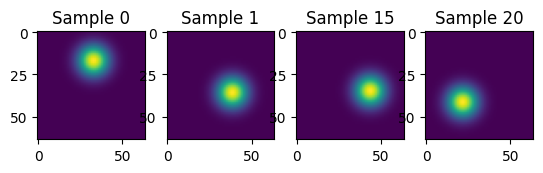

In [3]:
import matplotlib.pyplot as plt
plt.subplot(1, 4, 1)
plt.imshow(x_train[0, 0, :, :], cmap='viridis')
plt.title('Sample 0')
plt.subplot(1, 4, 2)
plt.imshow(x_train[1, 0, :, :], cmap='viridis')
plt.title('Sample 1')
plt.subplot(1, 4, 3)
plt.imshow(x_test[15, 0, :, :], cmap='viridis')
plt.title('Sample 15')
plt.subplot(1, 4, 4)
plt.imshow(x_test[20, 0, :, :], cmap='viridis')
plt.title('Sample 20')
plt.show()

# Prepare dataset

In [4]:
import torch
from torch.utils.data import Dataset

class GaussianCenterDataset(Dataset):
    """
    Wraps the generated Gaussian-blob images and their (x0, y0) centers.

    x: (N, 1, 64, 64) float32 image tensor
    p: (N, 2)         float32 center-position tensor
    """
    def __init__(self, x: np.ndarray, p: np.ndarray):
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.p = torch.as_tensor(p, dtype=torch.float32)

        assert self.x.shape[0] == self.p.shape[0], (
            f"Mismatched sample count: x has {self.x.shape[0]}, "
            f"p has {self.p.shape[0]}"
        )

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.p[idx]

In [5]:
from torch.utils.data import DataLoader

batch_size = 32  # < smallest classifier width (32), keeps StableSVD on the m > n branch
                  # for all 3 RRLayers, matching the official example's regime

train_dataset = GaussianCenterDataset(x_train, p_train)
test_dataset = GaussianCenterDataset(x_test, p_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

xb, pb = next(iter(train_loader))
print("batch x shape:", xb.shape)
print("batch p shape:", pb.shape)
print(f"batches per epoch: {len(train_loader)}")

batch x shape: torch.Size([32, 1, 64, 64])
batch p shape: torch.Size([32, 2])
batches per epoch: 25


# common make_feature_extractor()

In [6]:
def make_feature_extractor(depth: int = 3, norm: str | None = None,
                           rank: int = 8, svd_backend: str = "custom"):
    """
    Builds `depth` conv blocks. Channels go 1 -> 8 -> 16 -> 32.
    Pooling is removed, so spatial size stays D x D throughout.

    `norm` controls what sits between each Conv2d and its ReLU
    (i.e. the normalization comes BEFORE the activation):
      - None:  conv -> relu                    (plain OA)
      - "bn":  conv -> BatchNorm2d -> relu     (BN before activation)
      - "rr":  conv -> RRLayer -> relu         (RRLayer flattens (N, C, H, W)
               to a matrix internally and unflattens after -- the
               "flatten, RR, unflatten" step)
    """
    channel_sizes = [1, 8, 16, 32]
    if not (1 <= depth <= len(channel_sizes) - 1):
        raise ValueError(f"depth must be in [1, {len(channel_sizes) - 1}], got {depth}.")

    layers = []
    for i in range(depth):
        layers.append(nn.Conv2d(channel_sizes[i], channel_sizes[i + 1], kernel_size=3, padding=1))
        if norm == "bn":
            layers.append(nn.BatchNorm2d(channel_sizes[i + 1]))
        elif norm == "rr":
            layers.append(RRLayer(rank=rank, svd_backend=svd_backend))
        layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)


def feature_extractor_output_dim(depth: int, D: int = 64):
    """Flattened output size of make_feature_extractor(depth) for a D x D input (no pooling)."""
    channel_sizes = [1, 8, 16, 32]
    return channel_sizes[depth] * D * D

# Original Architecture

In [7]:
import torch
import torch.nn as nn


class OA(nn.Module):
    def __init__(self, depth: int = 3, D: int = 64):
        super(OA, self).__init__()
        self.features = make_feature_extractor(depth)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# Batch_Norm Architecture

In [8]:
class OA_BN(nn.Module):
    """BN after each layer (every conv and the hidden linear), always before the activation."""

    def __init__(self, depth: int = 3, D: int = 64):
        super(OA_BN, self).__init__()
        self.features = make_feature_extractor(depth, norm="bn")
        flat_dim = feature_extractor_output_dim(depth, D)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# RR_Layers Architecture

In [9]:
class OA_RR(nn.Module):
    """RRLayer after each layer (every conv and the hidden linear), always before the
    activation -- mirroring OA_BN's BN placement exactly. The flatten -> rank-reduce
    -> unflatten happens inside RRLayer.forward()."""

    def __init__(self, rank: int = 8, depth: int = 3, D: int = 64, svd_backend: str = "custom"):
        super(OA_RR, self).__init__()
        self.features = make_feature_extractor(depth, norm="rr", rank=rank, svd_backend=svd_backend)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), RRLayer(rank=rank, svd_backend=svd_backend), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# Experiment configuration & model builder

In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Global experiment configuration ----
N_SEEDS = 8                              # seeds per experiment; bump to 10 if runtime allows
SEEDS = list(range(2000, 2000 + N_SEEDS))

NTR_DEFAULT = 800
NTE_DEFAULT = 200
RANK = 8
EPOCHS_DEFAULT = 20
LR_DEFAULT = 1e-3
BATCH_SIZE = 32
DEPTH_DEFAULT = 3


def build_models(seed, depth=DEPTH_DEFAULT, rank=RANK, D=64, svd_backend="custom"):
    """
    Builds OA / OA_BN / OA_RR, re-applying the SAME seed before each
    constructor call, so their shared Conv2d/Linear layers get identical
    initial weights (verified positionally below) -- the only difference
    between the three models is the bottleneck.
    """
    torch.manual_seed(seed)
    model_oa = OA(depth=depth, D=D)

    torch.manual_seed(seed)
    model_bn = OA_BN(depth=depth, D=D)

    torch.manual_seed(seed)
    model_rr = OA_RR(rank=rank, depth=depth, D=D, svd_backend=svd_backend)

    return {"OA": model_oa, "OA_BN": model_bn, "OA_RR": model_rr}


print(f"Using device: {device}")
print(f"N_SEEDS={N_SEEDS}, SEEDS={SEEDS}")

Using device: cuda
N_SEEDS=8, SEEDS=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]


# Sanity check: shared initial weights across OA / OA_BN / OA_RR

In [11]:
def get_ordered_learnable_layers(model: nn.Module):
    """
    Returns a list of (weight, bias) tuples for every Conv2d/Linear
    layer in the model, in forward-pass order -- ignoring any
    BatchNorm/RRLayer/ReLU/etc. layers interspersed between them.
    """
    layers = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layers.append((module.weight, module.bias))
    return layers


def compare_shared_weights_by_position(models: dict):
    """
    Compares Conv2d/Linear weights positionally (1st conv vs 1st conv,
    2nd linear vs 2nd linear, etc.) rather than by state_dict key name,
    so BN/RRLayer insertions don't shift the comparison.
    """
    names = list(models.keys())
    ordered_layers = {n: get_ordered_learnable_layers(m) for n, m in models.items()}

    lengths = {n: len(ordered_layers[n]) for n in names}
    n_layers = min(lengths.values())

    for n in names:
        if lengths[n] != n_layers:
            print(f"warning: {n} has {lengths[n]} Conv2d/Linear layers, "
                  f"expected {max(lengths.values())} (mismatched architecture depth) "
                  f"-- only comparing the first {n_layers} shared positions")

    print(f"Comparing {n_layers} positionally-matched Conv2d/Linear layers "
          f"across: {names}\n" + "-" * 60)

    all_match = True
    for i in range(n_layers):
        ref_w, ref_b = ordered_layers[names[0]][i]
        for n in names[1:]:
            other_w, other_b = ordered_layers[n][i]

            if ref_w.shape != other_w.shape:
                print(f"[SHAPE MISMATCH] layer #{i}: "
                      f"{names[0]}={tuple(ref_w.shape)} vs {n}={tuple(other_w.shape)}")
                all_match = False
                continue

            w_match = torch.equal(ref_w, other_w)
            b_match = torch.equal(ref_b, other_b) if ref_b is not None else True

            if not (w_match and b_match):
                print(f"[MISMATCH] layer #{i} ({names[0]} vs {n}): "
                      f"weight_match={w_match}, bias_match={b_match}")
                all_match = False

    if all_match:
        print("All positionally-matched Conv2d/Linear layers have identical weights.")
    else:
        print("Some layers differ -- see above.")

    return all_match


_demo_models = build_models(seed=SEEDS[0])
compare_shared_weights_by_position(_demo_models)

Comparing 5 positionally-matched Conv2d/Linear layers across: ['OA', 'OA_BN', 'OA_RR']
------------------------------------------------------------
All positionally-matched Conv2d/Linear layers have identical weights.


True

# Training / evaluation / multi-seed infrastructure

In [12]:
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


def train_and_evaluate(models, train_loader, test_loader, device, epochs=20, lr=1e-3, verbose=False):
    criterion = nn.MSELoss()
    optimizers = {name: optim.Adam(m.parameters(), lr=lr) for name, m in models.items()}
    for m in models.values():
        m.to(device)

    train_loss_history = {name: [] for name in models}

    for epoch in range(epochs):
        for m in models.values():
            m.train()

        running = {name: 0.0 for name in models}
        for x_batch, p_batch in train_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            for name, model in models.items():
                opt = optimizers[name]
                opt.zero_grad()
                preds = model(x_batch)
                loss = criterion(preds, p_batch)
                loss.backward()
                opt.step()
                running[name] += loss.item() * x_batch.size(0)

        for name in models:
            train_loss_history[name].append(running[name] / len(train_loader.dataset))

        if verbose:
            msg = " | ".join(f"{name}: {train_loss_history[name][-1]:.4f}" for name in models)
            print(f"Epoch [{epoch + 1}/{epochs}] {msg}")

    for m in models.values():
        m.eval()

    results = {}
    with torch.no_grad():
        test_losses = {name: 0.0 for name in models}
        l2_dists = {name: [] for name in models}

        for x_batch, p_batch in test_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            for name, model in models.items():
                preds = model(x_batch)
                loss = criterion(preds, p_batch)
                test_losses[name] += loss.item() * x_batch.size(0)
                l2_dists[name].append(torch.linalg.norm(preds - p_batch, dim=1))

        for name in models:
            cat = torch.cat(l2_dists[name])
            test_mse = test_losses[name] / len(test_loader.dataset)
            train_mse_final = train_loss_history[name][-1]
            results[name] = {
                "test_mse": test_mse,
                "test_mean_l2": cat.mean().item(),
                "test_med_l2": cat.median().item(),
                "train_mse_final": train_mse_final,
                "gap": test_mse - train_mse_final,   # >0 => overfitting on this run
            }

    return results, train_loss_history


def run_single_experiment(seed, Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT, rank=RANK,
                           epochs=EPOCHS_DEFAULT, D=64, sigma=SIGMA, batch_size=BATCH_SIZE,
                           lr=LR_DEFAULT, svd_backend="custom", device=device, verbose=False):
    """Runs one full seed: fresh data -> fresh models (shared init) -> train -> eval."""
    x_tr, p_tr, x_te, p_te = generate_data(seed, Ntr=Ntr, Nte=Nte, D=D, sigma=sigma)

    train_loader = DataLoader(
        GaussianCenterDataset(x_tr, p_tr),
        batch_size=min(batch_size, Ntr), shuffle=True, drop_last=True,
    )
    test_loader = DataLoader(
        GaussianCenterDataset(x_te, p_te),
        batch_size=min(batch_size, Nte), shuffle=False,
    )

    models = build_models(seed, depth=depth, rank=rank, D=D, svd_backend=svd_backend)
    results, train_hist = train_and_evaluate(
        models, train_loader, test_loader, device, epochs=epochs, lr=lr, verbose=verbose
    )
    return results, train_hist


def run_multi_seed(seeds, **kwargs):
    """
    Repeats run_single_experiment across `seeds` and aggregates.
    Returns agg = {model_name: {metric_name: np.array of per-seed values}}.
    """
    per_seed_results = []
    for s in seeds:
        results, _ = run_single_experiment(seed=s, **kwargs)
        per_seed_results.append(results)

    model_names = list(per_seed_results[0].keys())
    metric_names = list(per_seed_results[0][model_names[0]].keys())

    agg = {
        name: {
            metric: np.array([r[name][metric] for r in per_seed_results])
            for metric in metric_names
        }
        for name in model_names
    }
    return agg, per_seed_results


colors = {'OA': 'tab:blue', 'OA_BN': 'tab:orange', 'OA_RR': 'tab:green'}


def plot_mean_std(agg, metrics=("test_mse", "test_mean_l2", "test_med_l2"), suptitle=None):
    """Bar plot of mean +- std across seeds, one panel per metric, for OA/OA_BN/OA_RR."""
    names = list(agg.keys())
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4.5))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        means = [agg[n][metric].mean() for n in names]
        stds = [agg[n][metric].std() for n in names]
        ax.bar(names, means, yerr=stds, capsize=6,
               color=[colors.get(n) for n in names], alpha=0.85)
        ax.set_title(metric)
        ax.grid(True, axis='y', alpha=0.3)
        # log scale: model losses can differ by orders of magnitude
        ax.set_yscale('symlog', linthresh=1e-3) if metric == 'gap' else ax.set_yscale('log')

    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


def plot_sweep(sweep_values, agg_list, metric, xlabel, title=None, ylabel=None, ax=None):
    """Grouped bar chart of mean +- std vs a swept variable (depth, Ntr, ...)."""
    model_names = list(agg_list[0].keys())
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 5))

    n_models = len(model_names)
    width = 0.8 / n_models
    x_base = np.arange(len(sweep_values))

    for i, name in enumerate(model_names):
        means = [agg[name][metric].mean() for agg in agg_list]
        stds = [agg[name][metric].std() for agg in agg_list]
        offset = (i - (n_models - 1) / 2) * width
        ax.bar(x_base + offset, means, width, yerr=stds, capsize=4,
               label=name, color=colors.get(name), alpha=0.85)

    ax.set_xticks(x_base)
    ax.set_xticklabels([str(v) for v in sweep_values])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or f"{metric} vs {xlabel}")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    # log scale so no single diverging model flattens the others; gap can be negative -> symlog
    if metric == 'gap':
        ax.set_yscale('symlog', linthresh=1e-2)
    else:
        ax.set_yscale('log')

    if own_fig:
        plt.tight_layout()
        plt.show()

# Baseline sanity check (single seed)

In [13]:
print("Baseline sanity check: single seed, depth=3, Ntr=800\n" + "=" * 60)

baseline_results, baseline_train_hist = run_single_experiment(
    seed=SEEDS[0], Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT,
    rank=RANK, epochs=EPOCHS_DEFAULT, svd_backend="custom", verbose=True,
)

print("\nFinal test metrics:")
for name, m in baseline_results.items():
    print(f"  {name:>5} | Test MSE: {m['test_mse']:.4f} | Mean L2: {m['test_mean_l2']:.4f} "
          f"| Med L2: {m['test_med_l2']:.4f} | Train MSE: {m['train_mse_final']:.4f} | Gap: {m['gap']:.4f}")

Baseline sanity check: single seed, depth=3, Ntr=800
Epoch [1/20] OA: 2.0922 | OA_BN: 0.2387 | OA_RR: 6.2197
Epoch [2/20] OA: 0.0250 | OA_BN: 0.0097 | OA_RR: 3.0510
Epoch [3/20] OA: 0.0012 | OA_BN: 0.0069 | OA_RR: 3.9535
Epoch [4/20] OA: 0.0002 | OA_BN: 0.0066 | OA_RR: 12.7998
Epoch [5/20] OA: 0.0001 | OA_BN: 0.0070 | OA_RR: 28.2624
Epoch [6/20] OA: 0.0000 | OA_BN: 0.0042 | OA_RR: 25.6137
Epoch [7/20] OA: 0.0000 | OA_BN: 0.0040 | OA_RR: 23.2817
Epoch [8/20] OA: 0.0000 | OA_BN: 0.0036 | OA_RR: 34.8217
Epoch [9/20] OA: 0.0000 | OA_BN: 0.0033 | OA_RR: 123.1341
Epoch [10/20] OA: 0.0000 | OA_BN: 0.0034 | OA_RR: 164.4310
Epoch [11/20] OA: 0.0000 | OA_BN: 0.0039 | OA_RR: 179.3169
Epoch [12/20] OA: 0.0000 | OA_BN: 0.0025 | OA_RR: 241.2741
Epoch [13/20] OA: 0.0000 | OA_BN: 0.0042 | OA_RR: 362.0186
Epoch [14/20] OA: 0.0000 | OA_BN: 0.0032 | OA_RR: 291.4068
Epoch [15/20] OA: 0.0000 | OA_BN: 0.0045 | OA_RR: 83.0223
Epoch [16/20] OA: 0.0000 | OA_BN: 0.0030 | OA_RR: 40.5343
Epoch [17/20] OA: 0.0000 

# Baseline plots

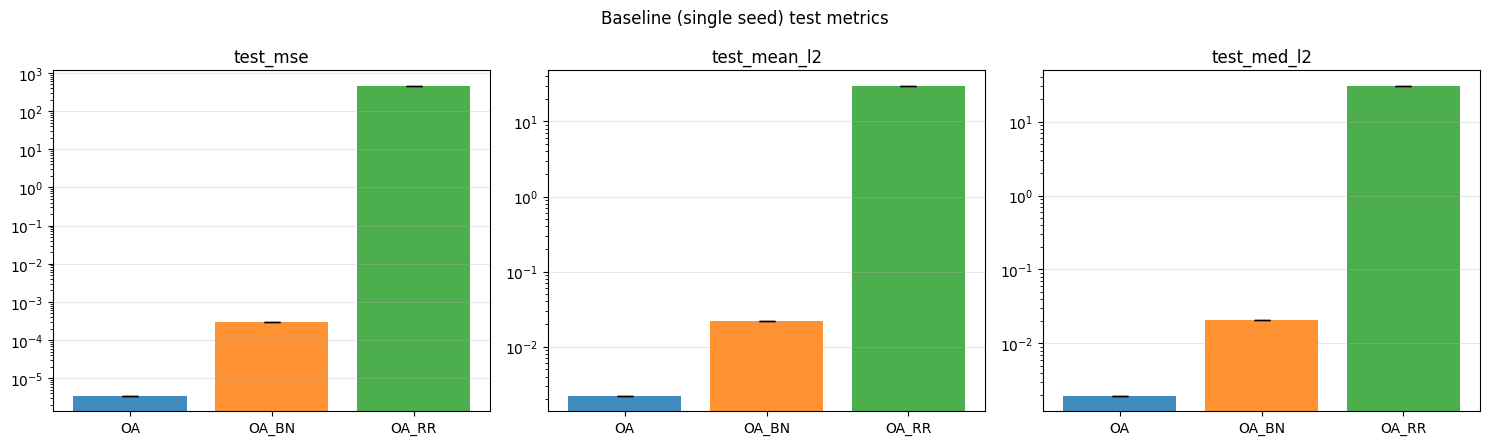

In [14]:
# Reuse plot_mean_std by wrapping the single-seed result in length-1 arrays
baseline_agg = {
    name: {k: np.array([v]) for k, v in m.items()}
    for name, m in baseline_results.items()
}
plot_mean_std(baseline_agg, metrics=("test_mse", "test_mean_l2", "test_med_l2"),
              suptitle="Baseline (single seed) test metrics")

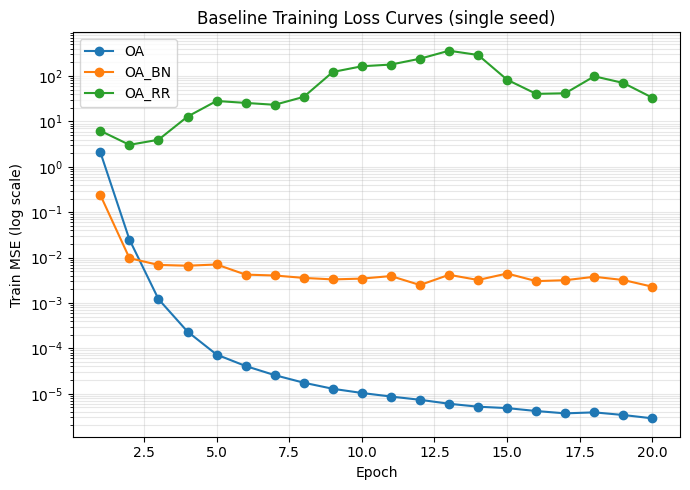

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, hist in baseline_train_hist.items():
    ax.plot(range(1, len(hist) + 1), hist, marker='o', label=name, color=colors[name])
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Train MSE (log scale)')
ax.set_title('Baseline Training Loss Curves (single seed)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Multi-seed comparison (mean ± std)

Running baseline multi-seed comparison: 8 seeds, depth=3, Ntr=800

Mean +- std across seeds:
     OA | Test MSE: 0.0000 +- 0.0000 | Mean L2: 0.0024 +- 0.0011 | Med L2: 0.0021 +- 0.0010
  OA_BN | Test MSE: 0.0008 +- 0.0004 | Mean L2: 0.0348 +- 0.0095 | Med L2: 0.0336 +- 0.0114
  OA_RR | Test MSE: 450.7924 +- 647.2927 | Mean L2: 21.5755 +- 20.5633 | Med L2: 21.4985 +- 20.7538


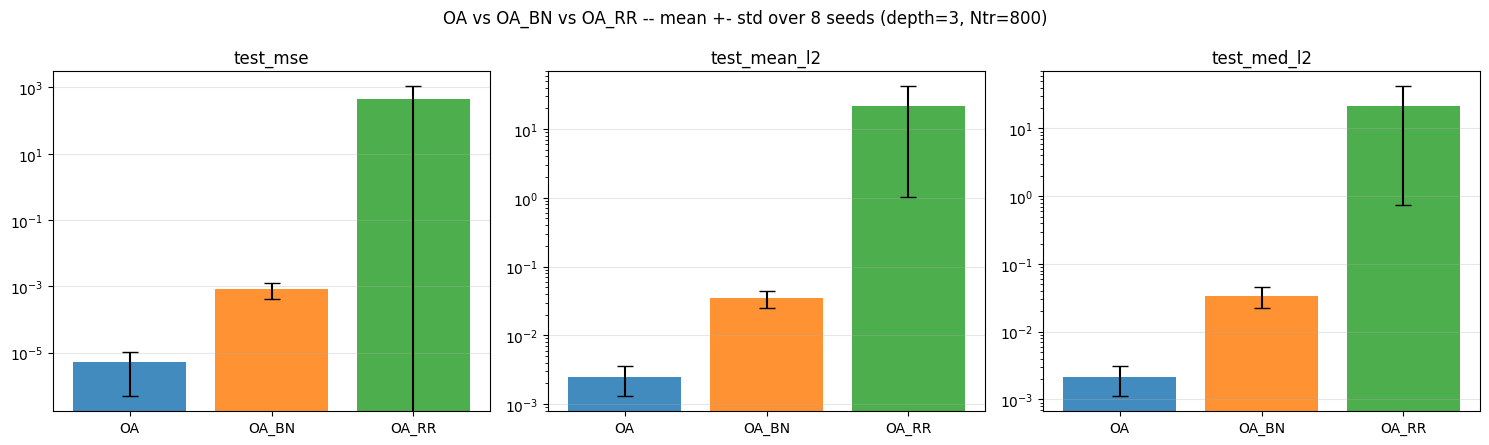

In [16]:
print(f"Running baseline multi-seed comparison: {N_SEEDS} seeds, depth={DEPTH_DEFAULT}, "
      f"Ntr={NTR_DEFAULT}\n" + "=" * 60)

baseline_agg_multi, baseline_per_seed = run_multi_seed(
    seeds=SEEDS, Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT,
    rank=RANK, epochs=EPOCHS_DEFAULT, svd_backend="custom",
)

print("\nMean +- std across seeds:")
for name, m in baseline_agg_multi.items():
    print(f"  {name:>5} | Test MSE: {m['test_mse'].mean():.4f} +- {m['test_mse'].std():.4f}"
          f" | Mean L2: {m['test_mean_l2'].mean():.4f} +- {m['test_mean_l2'].std():.4f}"
          f" | Med L2: {m['test_med_l2'].mean():.4f} +- {m['test_med_l2'].std():.4f}")

plot_mean_std(baseline_agg_multi, metrics=("test_mse", "test_mean_l2", "test_med_l2"),
              suptitle=f"OA vs OA_BN vs OA_RR -- mean +- std over {N_SEEDS} seeds "
                       f"(depth={DEPTH_DEFAULT}, Ntr={NTR_DEFAULT})")

# (when does OA start overfitting, and do BN/RR help?)

Running training-set-size sweep: [800, 500, 300, 150], 8 seeds each, depth=3
  Ntr=800 ...
  Ntr=500 ...
  Ntr=300 ...
  Ntr=150 ...


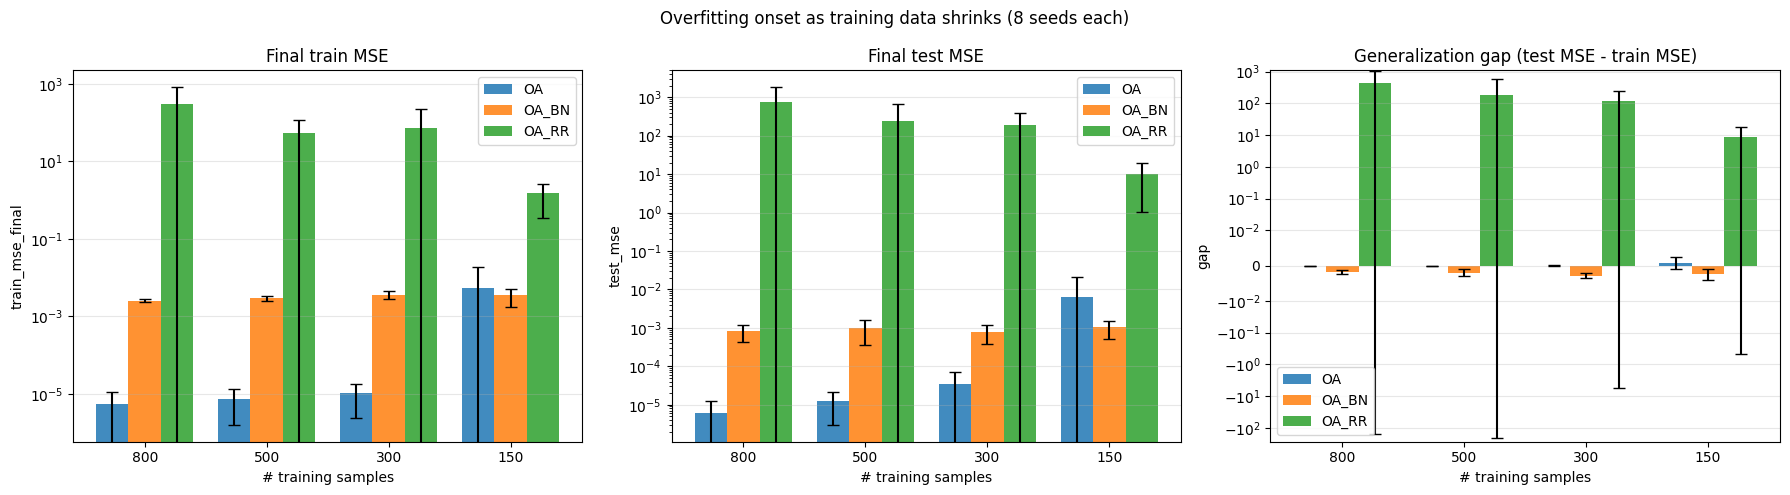

In [17]:
NTR_SWEEP = [800, 500, 300, 150]

print(f"Running training-set-size sweep: {NTR_SWEEP}, {N_SEEDS} seeds each, depth={DEPTH_DEFAULT}\n"
      + "=" * 60)

ntr_aggs = []
for ntr in NTR_SWEEP:
    print(f"  Ntr={ntr} ...")
    agg, _ = run_multi_seed(
        seeds=SEEDS, Ntr=ntr, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT,
        rank=RANK, epochs=EPOCHS_DEFAULT, svd_backend="custom",
    )
    ntr_aggs.append(agg)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_sweep(NTR_SWEEP, ntr_aggs, "train_mse_final", xlabel="# training samples",
           title="Final train MSE", ax=axes[0])
plot_sweep(NTR_SWEEP, ntr_aggs, "test_mse", xlabel="# training samples",
           title="Final test MSE", ax=axes[1])
plot_sweep(NTR_SWEEP, ntr_aggs, "gap", xlabel="# training samples",
           title="Generalization gap (test MSE - train MSE)", ylabel="gap", ax=axes[2])
plt.suptitle(f"Overfitting onset as training data shrinks ({N_SEEDS} seeds each)")
plt.tight_layout()
plt.show()

# RR warm-up: 10 epochs with RR, then RR stripped + features frozen, vs BN 20 epochs

Three arms from identical initial weights:
1. **OA_RR10_frozen10** - 10 epochs with RR layers active, then every RRLayer replaced by Identity, conv features frozen, classifier trained 10 more epochs.
2. **OA_BN_20ep** - straight 20 epochs with BN.
3. **OA_20ep** - plain OA control, 20 epochs.

Set `freeze_features=False` in the `strip_rr` call to keep the whole net trainable in phase 2.

RR warm-up experiment: 8 seeds
  seed 2000: OA_20ep 0.0000 | OA_BN_20ep 0.0006 | OA_RR10_frozen10 0.1601
  seed 2001: OA_20ep 0.0001 | OA_BN_20ep 0.0007 | OA_RR10_frozen10 0.0066
  seed 2002: OA_20ep 0.0000 | OA_BN_20ep 0.0008 | OA_RR10_frozen10 0.0513
  seed 2003: OA_20ep 0.0000 | OA_BN_20ep 0.0007 | OA_RR10_frozen10 0.0004
  seed 2004: OA_20ep 0.0000 | OA_BN_20ep 0.0004 | OA_RR10_frozen10 0.0236
  seed 2005: OA_20ep 0.0000 | OA_BN_20ep 0.0014 | OA_RR10_frozen10 0.0058
  seed 2006: OA_20ep 0.0000 | OA_BN_20ep 0.0007 | OA_RR10_frozen10 0.0226
  seed 2007: OA_20ep 0.0000 | OA_BN_20ep 0.0016 | OA_RR10_frozen10 0.0170


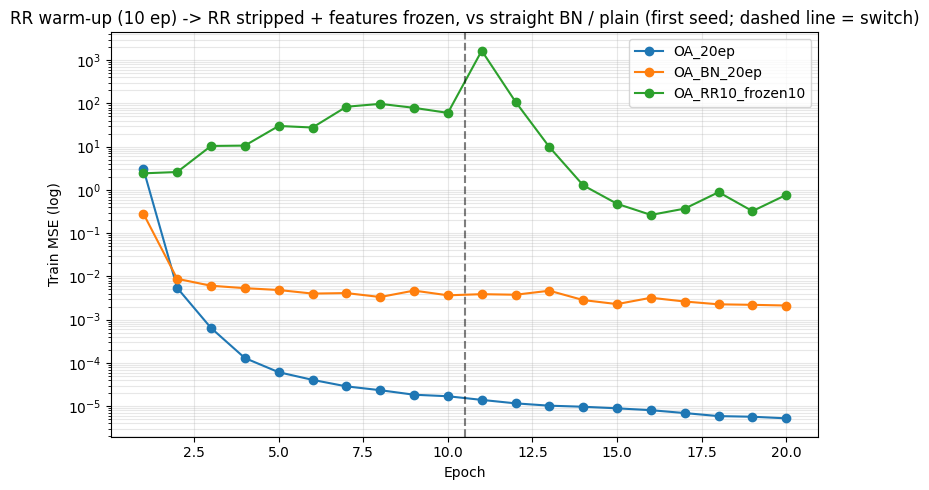

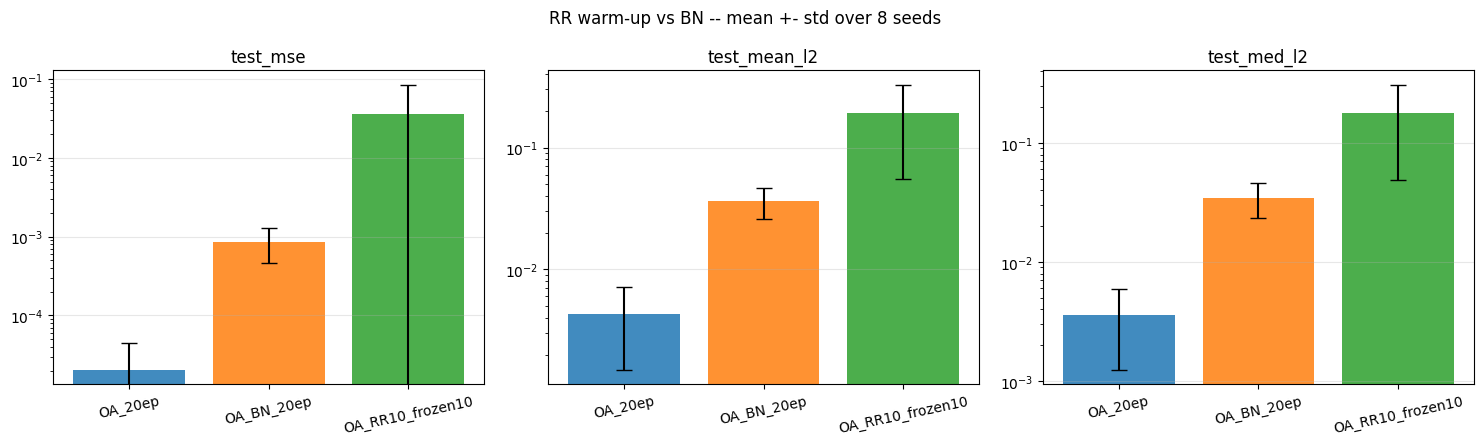


Mean +- std across seeds:
             OA_20ep | test MSE     0.0000 +-    0.0000 | mean L2   0.0043
          OA_BN_20ep | test MSE     0.0009 +-    0.0004 | mean L2   0.0362
    OA_RR10_frozen10 | test MSE     0.0359 +-    0.0492 | mean L2   0.1924


In [18]:
# === RR warm-up: 10 ep with RR -> strip RR + freeze features -> 10 ep, vs BN 20 ep ===
EPOCHS_RR, EPOCHS_FROZEN = 10, 10


def train_model(model, train_loader, device, epochs, lr=LR_DEFAULT):
    """Plain loop for one model; returns per-epoch train MSE."""
    criterion = nn.MSELoss()
    opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    model.to(device)
    history = []
    for _ in range(epochs):
        model.train()
        running = 0.0
        for x_batch, p_batch in train_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            opt.zero_grad()
            loss = criterion(model(x_batch), p_batch)
            loss.backward()
            opt.step()
            running += loss.item() * x_batch.size(0)
        history.append(running / len(train_loader.dataset))
    return history


def strip_rr(model, freeze_features=True):
    """Replace every RRLayer with Identity; optionally freeze the conv features."""
    for parent in model.modules():
        for name, child in list(parent.named_children()):
            if isinstance(child, RRLayer):
                setattr(parent, name, nn.Identity())
    if freeze_features:
        for p in model.features.parameters():
            p.requires_grad = False


@torch.no_grad()
def eval_model(model, test_loader, device):
    model.eval()
    criterion = nn.MSELoss()
    total, l2 = 0.0, []
    for x_batch, p_batch in test_loader:
        x_batch, p_batch = x_batch.to(device), p_batch.to(device)
        preds = model(x_batch)
        total += criterion(preds, p_batch).item() * x_batch.size(0)
        l2.append(torch.linalg.norm(preds - p_batch, dim=1))
    cat = torch.cat(l2)
    return {"test_mse": total / len(test_loader.dataset),
            "test_mean_l2": cat.mean().item(),
            "test_med_l2": cat.median().item()}


def run_warmup_seed(seed):
    x_tr, p_tr, x_te, p_te = generate_data(seed, Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, D=D, sigma=SIGMA)
    train_loader = DataLoader(GaussianCenterDataset(x_tr, p_tr),
                              batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(GaussianCenterDataset(x_te, p_te),
                             batch_size=BATCH_SIZE, shuffle=False)

    total_epochs = EPOCHS_RR + EPOCHS_FROZEN
    models = build_models(seed)   # shared init across all three arms
    hist, results = {}, {}

    # control: plain OA, 20 epochs
    torch.manual_seed(seed)   # same shuffle order for every arm
    hist["OA_20ep"] = train_model(models["OA"], train_loader, device, total_epochs)
    results["OA_20ep"] = eval_model(models["OA"], test_loader, device)

    # arm 2: OA_BN, straight 20 epochs
    torch.manual_seed(seed)
    hist["OA_BN_20ep"] = train_model(models["OA_BN"], train_loader, device, total_epochs)
    results["OA_BN_20ep"] = eval_model(models["OA_BN"], test_loader, device)

    # arm 1: 10 epochs with RR, then RR stripped + features frozen, 10 more epochs
    torch.manual_seed(seed)
    m = models["OA_RR"]
    h1 = train_model(m, train_loader, device, EPOCHS_RR)
    strip_rr(m, freeze_features=True)   # set False to keep the whole net trainable in phase 2
    h2 = train_model(m, train_loader, device, EPOCHS_FROZEN)   # fresh Adam, trainable params only
    hist["OA_RR10_frozen10"] = h1 + h2
    results["OA_RR10_frozen10"] = eval_model(m, test_loader, device)

    return results, hist


warm_colors = {"OA_20ep": "tab:blue", "OA_BN_20ep": "tab:orange", "OA_RR10_frozen10": "tab:green"}

print(f"RR warm-up experiment: {N_SEEDS} seeds\n" + "=" * 60)
per_seed, first_hist = [], None
for s in SEEDS:
    r, h = run_warmup_seed(s)
    per_seed.append(r)
    if first_hist is None:
        first_hist = h
    print(f"  seed {s}: " + " | ".join(f"{k} {v['test_mse']:.4f}" for k, v in r.items()))

warm_agg = {name: {metric: np.array([r[name][metric] for r in per_seed])
                   for metric in per_seed[0][name]}
            for name in per_seed[0]}

# -- viz 1: training curves (first seed), phase switch marked --
fig, ax = plt.subplots(figsize=(8, 5))
for name, h in first_hist.items():
    ax.plot(range(1, len(h) + 1), h, marker="o", label=name, color=warm_colors[name])
ax.axvline(EPOCHS_RR + 0.5, color="k", ls="--", alpha=0.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("Train MSE (log)")
ax.set_title(f"RR warm-up ({EPOCHS_RR} ep) -> RR stripped + features frozen, "
             f"vs straight BN / plain (first seed; dashed line = switch)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# -- viz 2: mean +- std bars over seeds --
names = list(warm_agg)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ("test_mse", "test_mean_l2", "test_med_l2")):
    means = [warm_agg[n][metric].mean() for n in names]
    stds = [warm_agg[n][metric].std() for n in names]
    ax.bar(names, means, yerr=stds, capsize=6,
           color=[warm_colors[n] for n in names], alpha=0.85)
    ax.set_title(metric); ax.set_yscale("log")
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=12)
plt.suptitle(f"RR warm-up vs BN -- mean +- std over {N_SEEDS} seeds")
plt.tight_layout(); plt.show()

print("\nMean +- std across seeds:")
for name, m in warm_agg.items():
    print(f"  {name:>18} | test MSE {m['test_mse'].mean():10.4f} +- {m['test_mse'].std():9.4f}"
          f" | mean L2 {m['test_mean_l2'].mean():8.4f}")

# Focused experiments: when does RR actually help?

The per-layer OA_RR diverges (see above), so these experiments use the classic **single bottleneck after flatten** for both BN and RR -- the placement from the earlier revision. Three questions:

1. **Noise robustness** -- the data lives on a 2-parameter manifold, so a rank-8 projection is a denoiser. Does RR win once the inputs are noisy?
2. **Rank sweep** (clean data) -- how much of RR's loss is the rank constraint? rank=32 (= batch size) is a no-op and should recover OA.
3. **Basis mismatch** -- same trained model, three inference strategies (per-batch SVD / averaged basis bank / full-train-data basis). Separates "rank truncation hurts" from "the eval basis is a bad estimate".

`SEEDS_FOCUS = SEEDS[:4]` keeps runtime sane; switch to `SEEDS` for the final poster numbers.

In [19]:
# --- single-bottleneck variants + shared helpers for the focused experiments ---
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

SEEDS_FOCUS = SEEDS[:4]   # bump to SEEDS for final numbers
colors = {'OA': 'tab:blue', 'OA_BN': 'tab:orange', 'OA_RR': 'tab:green'}


class OA_BN1(nn.Module):
    """Single BatchNorm1d bottleneck after flatten (earlier revision's placement)."""

    def __init__(self, depth: int = 3, D: int = 64):
        super().__init__()
        self.features = make_feature_extractor(depth)   # plain conv->relu, no pooling
        flat_dim = feature_extractor_output_dim(depth, D)
        self.bottleneck = nn.BatchNorm1d(flat_dim)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.bottleneck(torch.flatten(self.features(x), 1)))


class OA_RR1(nn.Module):
    """Single RRLayer bottleneck after flatten (earlier revision's placement)."""

    def __init__(self, rank: int = 8, depth: int = 3, D: int = 64, svd_backend: str = "custom"):
        super().__init__()
        self.features = make_feature_extractor(depth)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.bottleneck = RRLayer(rank=rank, svd_backend=svd_backend)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.classifier(self.bottleneck(torch.flatten(self.features(x), 1)))


def build_models1(seed, rank=RANK, svd_backend="custom"):
    """Same shared-init trick as build_models, single-bottleneck variants."""
    torch.manual_seed(seed)
    m_oa = OA()
    torch.manual_seed(seed)
    m_bn = OA_BN1()
    torch.manual_seed(seed)
    m_rr = OA_RR1(rank=rank, svd_backend=svd_backend)
    return {"OA": m_oa, "OA_BN": m_bn, "OA_RR": m_rr}


def add_input_noise(x, noise_std, seed):
    """Seeded additive Gaussian pixel noise."""
    if noise_std == 0.0:
        return x
    rng = np.random.RandomState(seed * 7919 + int(noise_std * 1000))
    return (x + noise_std * rng.randn(*x.shape)).astype(np.float32)


# redefined here so this section runs without executing the warm-up experiment above
def train_model(model, train_loader, device, epochs, lr=LR_DEFAULT):
    criterion = nn.MSELoss()
    opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    model.to(device)
    history = []
    for _ in range(epochs):
        model.train()
        running = 0.0
        for x_batch, p_batch in train_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            opt.zero_grad()
            loss = criterion(model(x_batch), p_batch)
            loss.backward()
            opt.step()
            running += loss.item() * x_batch.size(0)
        history.append(running / len(train_loader.dataset))
    return history


@torch.no_grad()
def eval_model(model, test_loader, device):
    model.eval()
    criterion = nn.MSELoss()
    total, l2 = 0.0, []
    for x_batch, p_batch in test_loader:
        x_batch, p_batch = x_batch.to(device), p_batch.to(device)
        preds = model(x_batch)
        total += criterion(preds, p_batch).item() * x_batch.size(0)
        l2.append(torch.linalg.norm(preds - p_batch, dim=1))
    cat = torch.cat(l2)
    return {"test_mse": total / len(test_loader.dataset),
            "test_mean_l2": cat.mean().item(),
            "test_med_l2": cat.median().item()}


def run_seed1(seed, noise_std=0.0, rank=RANK, only=None):
    """One seed: noisy data -> single-bottleneck models (shared init) -> train -> eval.
    Returns (results, context) -- context carries the trained models and loaders."""
    x_tr, p_tr, x_te, p_te = generate_data(seed, Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, D=D, sigma=SIGMA)
    x_tr = add_input_noise(x_tr, noise_std, seed)
    x_te = add_input_noise(x_te, noise_std, seed + 999)

    train_loader = DataLoader(GaussianCenterDataset(x_tr, p_tr),
                              batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    test_loader = DataLoader(GaussianCenterDataset(x_te, p_te),
                             batch_size=BATCH_SIZE, shuffle=False)

    models = build_models1(seed, rank=rank)
    if only is not None:
        models = {k: models[k] for k in only}

    results = {}
    for name, m in models.items():
        torch.manual_seed(seed)   # same shuffle order for every model
        train_model(m, train_loader, device, EPOCHS_DEFAULT)
        results[name] = eval_model(m, test_loader, device)

    return results, {"models": models, "train_loader": train_loader, "test_loader": test_loader}

## Experiment 1: noise robustness

Same task, additive Gaussian pixel noise on train and test images. If RR's low-rank projection acts as a denoiser, OA should degrade fastest as noise grows.

noise_std=0.0 (4 seeds) ...
noise_std=0.25 (4 seeds) ...
noise_std=0.5 (4 seeds) ...
noise_std=1.0 (4 seeds) ...


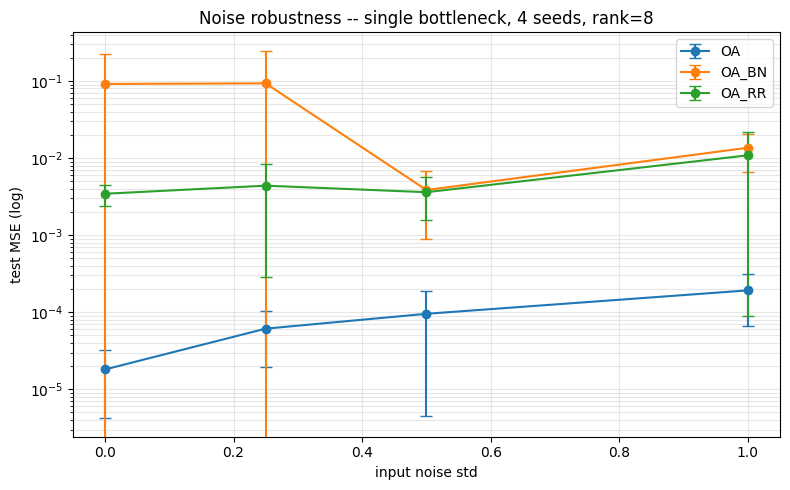

test MSE, mean +- std:
  noise=0.0   OA   0.0000 +-  0.0000 | OA_BN   0.0916 +-  0.1334 | OA_RR   0.0034 +-  0.0011
  noise=0.25  OA   0.0001 +-  0.0000 | OA_BN   0.0933 +-  0.1540 | OA_RR   0.0044 +-  0.0041
  noise=0.5   OA   0.0001 +-  0.0001 | OA_BN   0.0039 +-  0.0029 | OA_RR   0.0036 +-  0.0021
  noise=1.0   OA   0.0002 +-  0.0001 | OA_BN   0.0136 +-  0.0071 | OA_RR   0.0109 +-  0.0108


In [20]:
NOISE_LEVELS = [0.0, 0.25, 0.5, 1.0]

noise_aggs = {}
for ns in NOISE_LEVELS:
    print(f"noise_std={ns} ({len(SEEDS_FOCUS)} seeds) ...")
    per = []
    for s in SEEDS_FOCUS:
        res, _ = run_seed1(s, noise_std=ns)
        per.append(res)
    noise_aggs[ns] = {
        name: {m: np.array([r[name][m] for r in per]) for m in per[0][name]}
        for name in per[0]
    }

fig, ax = plt.subplots(figsize=(8, 5))
for name in ["OA", "OA_BN", "OA_RR"]:
    means = [noise_aggs[ns][name]["test_mse"].mean() for ns in NOISE_LEVELS]
    stds = [noise_aggs[ns][name]["test_mse"].std() for ns in NOISE_LEVELS]
    ax.errorbar(NOISE_LEVELS, means, yerr=stds, marker="o", capsize=4,
                label=name, color=colors[name])
ax.set_yscale("log")
ax.set_xlabel("input noise std")
ax.set_ylabel("test MSE (log)")
ax.set_title(f"Noise robustness -- single bottleneck, {len(SEEDS_FOCUS)} seeds, rank={RANK}")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("test MSE, mean +- std:")
for ns in NOISE_LEVELS:
    row = " | ".join(f"{n} {noise_aggs[ns][n]['test_mse'].mean():8.4f} +- {noise_aggs[ns][n]['test_mse'].std():7.4f}"
                     for n in ["OA", "OA_BN", "OA_RR"])
    print(f"  noise={ns:<5} {row}")

## Experiment 2: rank sweep (clean data)

Only OA_RR is retrained per rank; OA / OA_BN references (and rank=8) are reused from the noise sweep at noise=0, so **run Experiment 1 first**. rank=32 equals the batch size, so truncation is a no-op and OA_RR should recover plain OA.

rank=2 (4 seeds) ...
rank=4 (4 seeds) ...
rank=16 (4 seeds) ...


/tmp/ipykernel_2835/1128267744.py:357: UserWarning: Requested rank=16, but the maximum achievable rank is 8. Using rank=8.
  self._validate_inputs(x, basis)


rank=32 (4 seeds) ...


/tmp/ipykernel_2835/1128267744.py:357: UserWarning: Requested rank=32, but the maximum achievable rank is 8. Using rank=8.
  self._validate_inputs(x, basis)


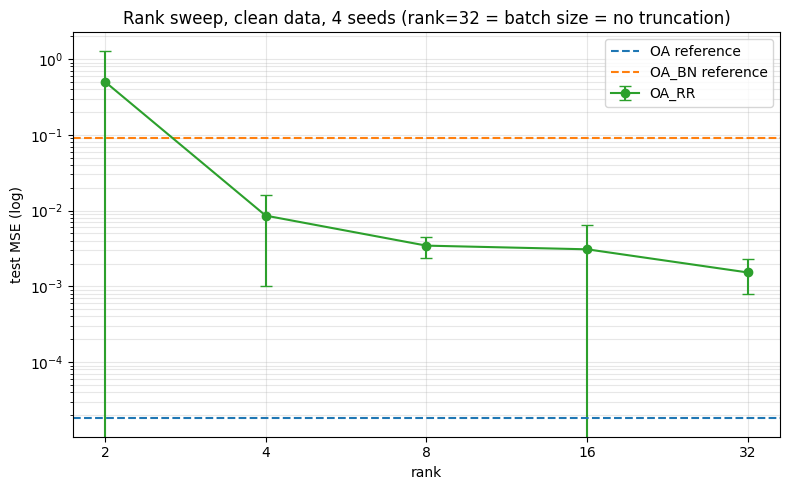

test MSE by rank, mean +- std:
  rank= 2 |   0.5028 +-  0.7864
  rank= 4 |   0.0086 +-  0.0076
  rank= 8 |   0.0034 +-  0.0011
  rank=16 |   0.0031 +-  0.0033
  rank=32 |   0.0015 +-  0.0007


In [21]:
RANKS = [2, 4, 8, 16, 32]

rank_mses = {RANK: noise_aggs[0.0]["OA_RR"]["test_mse"]}   # rank=8 reused from exp 1
for r in RANKS:
    if r in rank_mses:
        continue
    print(f"rank={r} ({len(SEEDS_FOCUS)} seeds) ...")
    vals = []
    for s in SEEDS_FOCUS:
        res, _ = run_seed1(s, noise_std=0.0, rank=r, only=("OA_RR",))
        vals.append(res["OA_RR"]["test_mse"])
    rank_mses[r] = np.array(vals)

fig, ax = plt.subplots(figsize=(8, 5))
means = [rank_mses[r].mean() for r in RANKS]
stds = [rank_mses[r].std() for r in RANKS]
ax.errorbar(RANKS, means, yerr=stds, marker="o", capsize=4,
            color=colors["OA_RR"], label="OA_RR")
ax.axhline(noise_aggs[0.0]["OA"]["test_mse"].mean(), color=colors["OA"],
           ls="--", label="OA reference")
ax.axhline(noise_aggs[0.0]["OA_BN"]["test_mse"].mean(), color=colors["OA_BN"],
           ls="--", label="OA_BN reference")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(RANKS)
ax.set_xticklabels([str(r) for r in RANKS])
ax.set_xlabel("rank")
ax.set_ylabel("test MSE (log)")
ax.set_title(f"Rank sweep, clean data, {len(SEEDS_FOCUS)} seeds "
             f"(rank=32 = batch size = no truncation)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("test MSE by rank, mean +- std:")
for r in RANKS:
    print(f"  rank={r:>2} | {rank_mses[r].mean():8.4f} +- {rank_mses[r].std():7.4f}")

## Experiment 3: where does RR's loss come from?

One trained OA_RR per seed, evaluated three ways:
- **per-batch SVD (train mode)** -- the exact operation training saw. Its gap to OA = cost of the rank constraint alone.
- **basis bank (default eval)** -- SVD of concatenated recent minibatch bases. Its gap to train mode = cost of basis *estimation*.
- **full-data basis** -- `finalize_basis_from_data` on the whole train set's features, the best possible fixed basis.

seed 2000 ...
seed 2001 ...
seed 2002 ...
seed 2003 ...


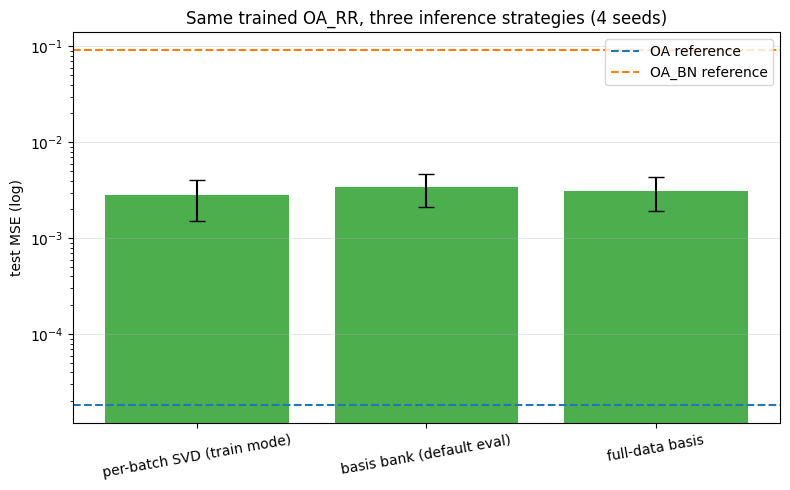

test MSE, mean +- std:
  per-batch SVD (train mode) |   0.0028 +-  0.0013
   basis bank (default eval) |   0.0034 +-  0.0013
             full-data basis |   0.0031 +-  0.0012
                OA reference |   0.0000


In [22]:
STRATS = ["per-batch SVD (train mode)", "basis bank (default eval)", "full-data basis"]
mismatch = {k: [] for k in STRATS}

for s in SEEDS_FOCUS:
    print(f"seed {s} ...")
    res, ctx = run_seed1(s, noise_std=0.0, only=("OA_RR",))
    model = ctx["models"]["OA_RR"]
    test_loader = ctx["test_loader"]

    # 1) default eval already computed by run_seed1 (basis-bank inference basis)
    mismatch["basis bank (default eval)"].append(res["OA_RR"]["test_mse"])

    # 2) train-mode eval: per-batch SVD on the test batches, no grad
    model.train()
    total = 0.0
    with torch.no_grad():
        for xb, pb in test_loader:
            xb, pb = xb.to(device), pb.to(device)
            total += nn.functional.mse_loss(model(xb), pb).item() * xb.size(0)
    mismatch["per-batch SVD (train mode)"].append(total / len(test_loader.dataset))

    # 3) basis from the full training set's features
    model.eval()
    feats = []
    with torch.no_grad():
        for xb, _ in ctx["train_loader"]:
            feats.append(torch.flatten(model.features(xb.to(device)), 1))
    model.bottleneck.finalize_basis_from_data(torch.cat(feats))
    mismatch["full-data basis"].append(eval_model(model, test_loader, device)["test_mse"])

fig, ax = plt.subplots(figsize=(8, 5))
means = [np.mean(mismatch[k]) for k in STRATS]
stds = [np.std(mismatch[k]) for k in STRATS]
ax.bar(STRATS, means, yerr=stds, capsize=6, color=colors["OA_RR"], alpha=0.85)
ax.axhline(noise_aggs[0.0]["OA"]["test_mse"].mean(), color=colors["OA"],
           ls="--", label="OA reference")
ax.axhline(noise_aggs[0.0]["OA_BN"]["test_mse"].mean(), color=colors["OA_BN"],
           ls="--", label="OA_BN reference")
ax.set_yscale("log")
ax.set_ylabel("test MSE (log)")
ax.set_title(f"Same trained OA_RR, three inference strategies ({len(SEEDS_FOCUS)} seeds)")
ax.tick_params(axis="x", rotation=10)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("test MSE, mean +- std:")
for k in STRATS:
    print(f"  {k:>26} | {np.mean(mismatch[k]):8.4f} +- {np.std(mismatch[k]):7.4f}")
print(f"  {'OA reference':>26} | {noise_aggs[0.0]['OA']['test_mse'].mean():8.4f}")

## Experiment 4: small data + heavy noise

The only untested regime where plain OA could plausibly lose: few training samples AND noisy inputs. Noise fixed at 1.0, Ntr swept down to 50. Epochs are scaled up as data shrinks so every config gets a comparable number of gradient updates (otherwise small-Ntr runs barely train and nothing can overfit). Reports the train/test gap explicitly -- that's the overfitting signal.

Ntr=50, noise=1.0 (4 seeds) ...
Ntr=100, noise=1.0 (4 seeds) ...
Ntr=200, noise=1.0 (4 seeds) ...
Ntr=400, noise=1.0 (4 seeds) ...


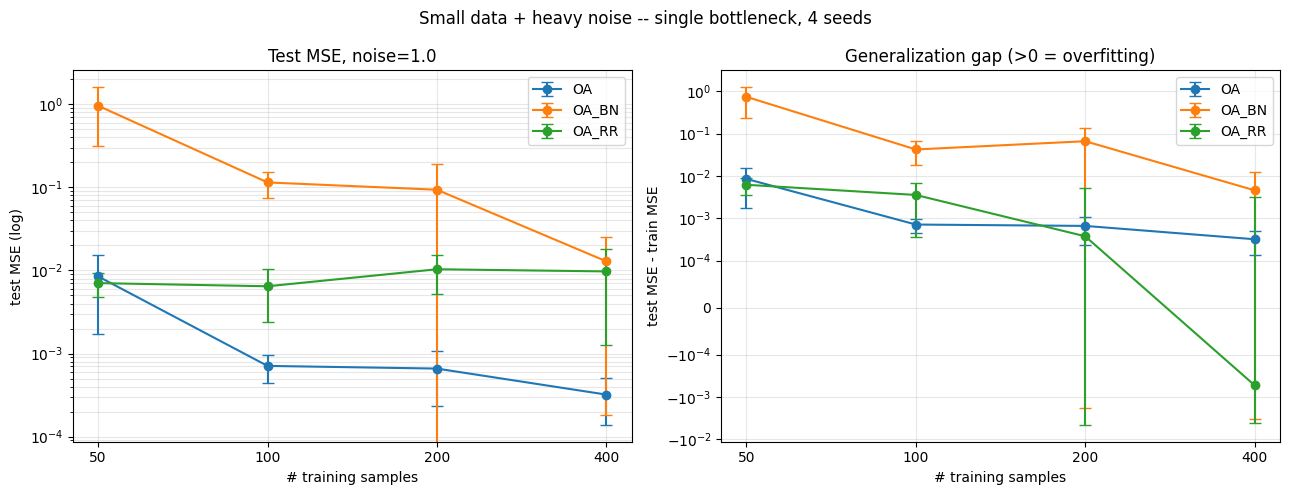

mean +- std across seeds:
  Ntr=50
       OA | train   0.0000 | test   0.0085 +-  0.0068 | gap   0.0085
    OA_BN | train   0.2257 | test   0.9610 +-  0.6466 | gap   0.7353
    OA_RR | train   0.0009 | test   0.0070 +-  0.0023 | gap   0.0062
  Ntr=100
       OA | train   0.0000 | test   0.0007 +-  0.0003 | gap   0.0007
    OA_BN | train   0.0727 | test   0.1148 +-  0.0401 | gap   0.0420
    OA_RR | train   0.0029 | test   0.0065 +-  0.0041 | gap   0.0035
  Ntr=200
       OA | train   0.0000 | test   0.0007 +-  0.0004 | gap   0.0007
    OA_BN | train   0.0278 | test   0.0937 +-  0.0977 | gap   0.0659
    OA_RR | train   0.0100 | test   0.0103 +-  0.0052 | gap   0.0004
  Ntr=400
       OA | train   0.0000 | test   0.0003 +-  0.0002 | gap   0.0003
    OA_BN | train   0.0083 | test   0.0129 +-  0.0127 | gap   0.0046
    OA_RR | train   0.0103 | test   0.0097 +-  0.0085 | gap  -0.0005


In [23]:
NTR_SMALL = [50, 100, 200, 400]
NOISE_SMALL = 1.0


def run_seed_small(seed, ntr, noise_std=NOISE_SMALL, rank=RANK):
    """Like run_seed1 but with Ntr as a knob and epochs scaled to keep total updates comparable."""
    x_tr, p_tr, x_te, p_te = generate_data(seed, Ntr=ntr, Nte=NTE_DEFAULT, D=D, sigma=SIGMA)
    x_tr = add_input_noise(x_tr, noise_std, seed)
    x_te = add_input_noise(x_te, noise_std, seed + 999)

    train_loader = DataLoader(GaussianCenterDataset(x_tr, p_tr),
                              batch_size=min(BATCH_SIZE, ntr), shuffle=True, drop_last=True)
    test_loader = DataLoader(GaussianCenterDataset(x_te, p_te),
                             batch_size=BATCH_SIZE, shuffle=False)

    epochs = EPOCHS_DEFAULT * max(1, NTR_DEFAULT // ntr)   # same update budget as Ntr=800

    models = build_models1(seed, rank=rank)
    results = {}
    for name, m in models.items():
        torch.manual_seed(seed)
        hist = train_model(m, train_loader, device, epochs)
        r = eval_model(m, test_loader, device)
        r["train_mse_final"] = hist[-1]
        r["gap"] = r["test_mse"] - hist[-1]
        results[name] = r
    return results


small_aggs = []
for ntr in NTR_SMALL:
    print(f"Ntr={ntr}, noise={NOISE_SMALL} ({len(SEEDS_FOCUS)} seeds) ...")
    per = [run_seed_small(s, ntr) for s in SEEDS_FOCUS]
    small_aggs.append({
        name: {m: np.array([r[name][m] for r in per]) for m in per[0][name]}
        for name in per[0]
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in ["OA", "OA_BN", "OA_RR"]:
    means = [agg[name]["test_mse"].mean() for agg in small_aggs]
    stds = [agg[name]["test_mse"].std() for agg in small_aggs]
    axes[0].errorbar(NTR_SMALL, means, yerr=stds, marker="o", capsize=4,
                     label=name, color=colors[name])
    gmeans = [agg[name]["gap"].mean() for agg in small_aggs]
    gstds = [agg[name]["gap"].std() for agg in small_aggs]
    axes[1].errorbar(NTR_SMALL, gmeans, yerr=gstds, marker="o", capsize=4,
                     label=name, color=colors[name])

axes[0].set_yscale("log")
axes[0].set_xlabel("# training samples")
axes[0].set_ylabel("test MSE (log)")
axes[0].set_title(f"Test MSE, noise={NOISE_SMALL}")
axes[1].set_yscale("symlog", linthresh=1e-4)
axes[1].set_xlabel("# training samples")
axes[1].set_ylabel("test MSE - train MSE")
axes[1].set_title("Generalization gap (>0 = overfitting)")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(NTR_SMALL)
    ax.set_xticklabels([str(n) for n in NTR_SMALL])
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
plt.suptitle(f"Small data + heavy noise -- single bottleneck, {len(SEEDS_FOCUS)} seeds")
plt.tight_layout()
plt.show()

print("mean +- std across seeds:")
for ntr, agg in zip(NTR_SMALL, small_aggs):
    print(f"  Ntr={ntr}")
    for name in ["OA", "OA_BN", "OA_RR"]:
        m = agg[name]
        print(f"    {name:>5} | train {m['train_mse_final'].mean():8.4f} "
              f"| test {m['test_mse'].mean():8.4f} +- {m['test_mse'].std():7.4f} "
              f"| gap {m['gap'].mean():8.4f}")

## Experiment 5: astronomy-style noise (source localization framing)

The task -- regress a Gaussian blob's center from a noisy image -- is exactly point-source localization (PSF centroid estimation), the canonical problem in astrometry and single-molecule microscopy, where truncated-SVD projections (KLIP, Kepler cotrending basis vectors) are standard noise-suppression tools. Real detector noise is not i.i.d.: photon shot noise is signal-dependent, and systematics are *structured* -- a few spatial patterns shared across exposures, i.e. literally low-rank. This experiment compares the three models at Ntr=200 under:

- **gaussian** -- i.i.d. pixel noise (reference, matches Experiment 1/4)
- **shot** -- photon-like: noise scales with sqrt(brightness), concentrated on the source
- **structured** -- a fixed bank of smooth patterns (gradients + waves) with random per-image coefficients: a low-rank nuisance, the exact regime KLIP-style projection targets

Hypothesis: RR should gain the most (or lose the least) under structured noise; if instead the nuisance dominates the top singular components and RR keeps it, that's an equally reportable failure mode.

noise kind: gaussian (4 seeds) ...
noise kind: shot (4 seeds) ...
noise kind: structured (4 seeds) ...


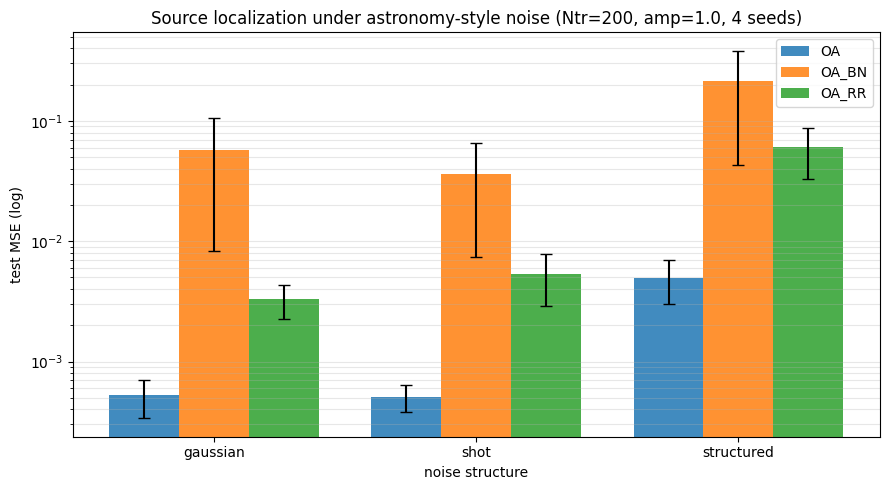

test MSE, mean +- std:
    gaussian: OA   0.0005 +-  0.0002 | OA_BN   0.0573 +-  0.0489 | OA_RR   0.0033 +-  0.0010
        shot: OA   0.0005 +-  0.0001 | OA_BN   0.0362 +-  0.0288 | OA_RR   0.0054 +-  0.0025
  structured: OA   0.0050 +-  0.0020 | OA_BN   0.2130 +-  0.1700 | OA_RR   0.0602 +-  0.0276


In [24]:
NTR_ASTRO = 200
ASTRO_AMP = 1.0
ASTRO_KINDS = ["gaussian", "shot", "structured"]


def _pattern_bank(D=64, n_patterns=4, seed=777):
    """Fixed 'detector systematics': smooth gradients + waves, unit std each.
    Seeded independently of the data so train/test share the same patterns."""
    rng = np.random.RandomState(seed)
    xs = np.linspace(-1, 1, D)
    X, Y = np.meshgrid(xs, xs)
    pats = []
    for _ in range(n_patterns):
        a, b = rng.randn(2)
        p = a * X + b * Y + np.sin(2 * np.pi * (rng.rand() * 2 * X + rng.rand() * 2 * Y))
        pats.append(p / p.std())
    return np.stack(pats).astype(np.float32)   # (K, D, D)


ASTRO_PATTERNS = _pattern_bank(D=D)


def add_astro_noise(x, kind, seed, amp=ASTRO_AMP):
    rng = np.random.RandomState(seed * 6151 + hash(kind) % 100003)
    if kind == "gaussian":
        return (x + amp * rng.randn(*x.shape)).astype(np.float32)
    if kind == "shot":   # photon-like: stronger where the image is brighter
        return (x + amp * np.sqrt(np.abs(x)) * rng.randn(*x.shape)).astype(np.float32)
    if kind == "structured":   # low-rank nuisance: shared patterns, random strength per image
        coeffs = amp * rng.randn(x.shape[0], len(ASTRO_PATTERNS)).astype(np.float32)
        nuisance = np.einsum("nk,khw->nhw", coeffs, ASTRO_PATTERNS)[:, None]
        return x + nuisance
    raise ValueError(kind)


def run_seed_astro(seed, kind, ntr=NTR_ASTRO, rank=RANK):
    x_tr, p_tr, x_te, p_te = generate_data(seed, Ntr=ntr, Nte=NTE_DEFAULT, D=D, sigma=SIGMA)
    x_tr = add_astro_noise(x_tr, kind, seed)
    x_te = add_astro_noise(x_te, kind, seed + 999)

    train_loader = DataLoader(GaussianCenterDataset(x_tr, p_tr),
                              batch_size=min(BATCH_SIZE, ntr), shuffle=True, drop_last=True)
    test_loader = DataLoader(GaussianCenterDataset(x_te, p_te),
                             batch_size=BATCH_SIZE, shuffle=False)

    epochs = EPOCHS_DEFAULT * max(1, NTR_DEFAULT // ntr)   # same update budget as Ntr=800

    models = build_models1(seed, rank=rank)
    results = {}
    for name, m in models.items():
        torch.manual_seed(seed)
        train_model(m, train_loader, device, epochs)
        results[name] = eval_model(m, test_loader, device)
    return results


astro_aggs = {}
for kind in ASTRO_KINDS:
    print(f"noise kind: {kind} ({len(SEEDS_FOCUS)} seeds) ...")
    per = [run_seed_astro(s, kind) for s in SEEDS_FOCUS]
    astro_aggs[kind] = {
        name: np.array([r[name]["test_mse"] for r in per]) for name in per[0]
    }

fig, ax = plt.subplots(figsize=(9, 5))
model_names = ["OA", "OA_BN", "OA_RR"]
width = 0.8 / len(model_names)
x_base = np.arange(len(ASTRO_KINDS))
for i, name in enumerate(model_names):
    means = [astro_aggs[k][name].mean() for k in ASTRO_KINDS]
    stds = [astro_aggs[k][name].std() for k in ASTRO_KINDS]
    ax.bar(x_base + (i - 1) * width, means, width, yerr=stds, capsize=4,
           label=name, color=colors[name], alpha=0.85)
ax.set_xticks(x_base)
ax.set_xticklabels(ASTRO_KINDS)
ax.set_yscale("log")
ax.set_xlabel("noise structure")
ax.set_ylabel("test MSE (log)")
ax.set_title(f"Source localization under astronomy-style noise "
             f"(Ntr={NTR_ASTRO}, amp={ASTRO_AMP}, {len(SEEDS_FOCUS)} seeds)")
ax.legend()
ax.grid(True, axis="y", which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("test MSE, mean +- std:")
for kind in ASTRO_KINDS:
    row = " | ".join(f"{n} {astro_aggs[kind][n].mean():8.4f} +- {astro_aggs[kind][n].std():7.4f}"
                     for n in model_names)
    print(f"  {kind:>10}: {row}")